# Model C: CatBoost + Feature Engineering con GMM

> **Dataset:** Stroke Prediction Dataset (Kaggle)  
> **Fuente:** https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset  
> **Algoritmo principal:** CatBoost Classifier  
> **Feature Engineering:** Gaussian Mixture Model (GMM)  
> **Búsqueda de hiperparámetros:** Optuna  

---
## 1. Justificación de la Elección del Algoritmo: CatBoost

### ¿Por qué CatBoost y no otro algoritmo de boosting?

Cuando empecé a analizar el dataset, lo primero que noté fue la presencia de varias variables categóricas: `gender`, `ever_married`, `work_type`, `Residence_type` y `smoking_status`. En la mayoría de los algoritmos de machine learning, estas variables requieren un preprocesamiento explícito antes de ser utilizadas — ya sea One-Hot Encoding (OHE) o Label Encoding — y cada uno de estos métodos tiene sus propios problemas.

El OHE expande la dimensionalidad del dataset, lo que puede perjudicar el rendimiento en datasets pequeños como este (~5000 registros). El Label Encoding, por otro lado, introduce un orden artificial entre categorías que no necesariamente existe.

**CatBoost resuelve esto de forma nativa.** Implementa una técnica llamada **Ordered Target Statistics (OTS)**, que calcula una representación numérica de cada categoría utilizando únicamente las observaciones que aparecen *antes* de la actual en el orden de entrenamiento. Esto evita el **data leakage** que ocurre con el Target Encoding clásico, donde se usa toda la información del fold de entrenamiento para calcular el encoding, contaminando indirectamente el modelo con información del target.

Además del manejo de categorías, identifiqué otras razones importantes para elegir CatBoost en este problema:

1. **Desbalance de clases nativo:** El dataset tiene aproximadamente 95% de casos negativos (no stroke) y 5% positivos. CatBoost permite especificar directamente el parámetro `scale_pos_weight` o usar `auto_class_weights='Balanced'`, que ajusta los pesos de las clases durante el entrenamiento sin necesidad de técnicas externas como SMOTE.

2. **Symmetric Trees:** A diferencia de XGBoost y LightGBM que construyen árboles asimétricamente (creciendo por el nodo con mayor ganancia), CatBoost construye árboles *oblivious* o simétricos, donde todos los nodos de un mismo nivel usan el mismo criterio de split. Esto reduce significativamente el overfitting, algo especialmente importante dado el pequeño tamaño del dataset.

3. **Robustez con pocos datos:** He leído en la documentación oficial y en benchmarks publicados que CatBoost tiende a superar a XGBoost y LightGBM en datasets pequeños y medianos, justamente por la combinación de árboles simétricos y el mecanismo de Ordered Boosting que reduce el sesgo de predicción.

4. **Menos hiperparámetros críticos:** CatBoost tiene buenos valores por defecto y es menos sensible al overfitting sin regularización explícita que XGBoost, lo que lo hace más fácil de tunear con Optuna sin explorar espacios de búsqueda extremadamente grandes.

En resumen, la elección de CatBoost no fue arbitraria: responde directamente a las características del dataset (variables categóricas, desbalance severo, tamaño moderado) y se sustenta en propiedades algorítmicas concretas que lo diferencian de sus competidores.

---
## 2. Justificación del Feature Engineering con GMM

### ¿Por qué aplicar GMM como técnica de Feature Engineering?

Mientras realizaba el análisis exploratorio del dataset, noté algo interesante en las distribuciones de tres variables numéricas continuas: `age`, `avg_glucose_level` y `bmi`. Ninguna de estas distribuciones es gaussiana simple — todas muestran formas multimodales que sugieren la existencia de **subpoblaciones diferenciadas** dentro del dataset.

Esto no es casualidad: tiene una explicación médica concreta.

- `avg_glucose_level`: Los niveles de glucosa en ayunas se usan clínicamente para clasificar a los pacientes en **normoglucémicos** (<100 mg/dL), **prediabéticos** (100-125 mg/dL) y **diabéticos** (>126 mg/dL). Es esperable que la distribución sea trimodal.
- `bmi`: El índice de masa corporal define categorías médicas: **bajo peso** (<18.5), **normal** (18.5-24.9), **sobrepeso** (25-29.9) y **obeso** (>30). La distribución debería reflejar estas poblaciones.
- `age`: El riesgo de ACV aumenta con la edad, pero no linealmente. Existe una diferencia cualitativa entre adultos jóvenes, adultos de mediana edad y adultos mayores en términos de factores de riesgo acumulados.

La pregunta entonces fue: ¿puede CatBoost capturar estas subpoblaciones por sí solo, o podemos ayudarlo dándole esa información explícitamente?

Mi hipótesis es que aunque CatBoost puede aprender splits en estas variables, hacerlo de manera explícita mediante GMM le ofrece **información pre-digerida** sobre la estructura latente de los datos, potencialmente mejorando su capacidad de generalización.

### ¿Por qué GMM y no K-Means?

Consideré usar K-Means inicialmente, pero lo descarté por dos razones fundamentales:

1. **K-Means hace asignaciones duras (hard assignment):** Cada observación pertenece a exactamente un cluster. Pero en la realidad médica, un paciente con glucosa en 110 mg/dL está en una zona ambigua entre normal y prediabético. Forzar una asignación binaria pierde esa incertidumbre.

2. **GMM modela la incertidumbre mediante probabilidades (soft assignment):** El modelo devuelve, para cada observación, la probabilidad de pertenecer a cada componente gaussiana. Estas probabilidades continuas son features mucho más ricas para CatBoost, ya que preservan la gradación entre grupos.

Esto tiene además una justificación estadística sólida: GMM es un modelo generativo que asume que los datos fueron generados por una mezcla de distribuciones gaussianas. Dado que las variables biométricas tienden a tener distribuciones aproximadamente normales dentro de subpoblaciones homogéneas, esta asunción es razonable.

### Diseño del experimento

Para evaluar si GMM realmente aporta valor, diseñé tres experimentos comparativos:

| Experimento | Features adicionales | Objetivo |
|---|---|---|
| **Baseline** | Ninguna | Referencia sin GMM |
| **GMM Hard** | `gmm_cluster` (label discreto) | Versión simple |
| **GMM Soft** | `gmm_proba_k` (probabilidades continuas) | Versión rica |

La métrica principal de comparación será **AUC-ROC** y **Recall de la clase positiva (stroke=1)**, ya que en un contexto médico es preferible un falso positivo (paciente sano clasificado como riesgo) a un falso negativo (paciente con riesgo de ACV no detectado).

---
## 3. Imports y Configuración

In [1]:
# ─── Librerías estándar ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualización ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import sys
import os

# Agrega el directorio raíz del proyecto al path
sys.path.append(os.path.abspath(os.path.join('..')))

# ─── Preprocesamiento ─────────────────────────────────────────────────────────
from src.data_loader import load_dataset, clean_data_id_gender, get_train_test_split , impute_bmi_knn, TARGET_COL
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ─── GMM ──────────────────────────────────────────────────────────────────────
from sklearn.mixture import GaussianMixture

# ─── CatBoost ─────────────────────────────────────────────────────────────────
from catboost import CatBoostClassifier, Pool

# ─── Métricas ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_recall_curve,
    average_precision_score
)

# ─── Optuna ───────────────────────────────────────────────────────────────────
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─── Reproducibilidad ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


---
## 4. Carga y Preprocesamiento del Dataset

In [2]:
# ─── Carga del dataset ────────────────────────────────────────────────────────
df_original = load_dataset()
print(f"Shape original: {df_original.shape}")
print(f"\nValores nulos por columna:")
print(df_original.isnull().sum())
print(f"\nDistribución del target:")
print(df_original['stroke'].value_counts(normalize=True).round(4) * 100)

Loaded dataset: 5110 rows, 12 columns.
Shape original: (5110, 12)

Valores nulos por columna:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Distribución del target:
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


In [3]:
# ─── Preprocesamiento ─────────────────────────────────────────────────────────
# Eliminar columna ID (no aporta información predictiva) y 
# eliminar el único registro con gender='Other' (outlier extremo)
df = df_original.copy()
df = clean_data_id_gender(df)

# Separar features y target
X = df.drop(columns=['stroke'])
y = df['stroke']

# Identificar columnas categóricas para CatBoost
cat_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
cat_feature_indices = [X.columns.get_loc(c) for c in cat_features]

# Split estratificado: mantener la proporción de clases en train y test
X_train, X_test, y_train, y_test = get_train_test_split(df, 'stroke', 0.2,SEED)


print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Positivos en train: {y_train.mean():.3%} | en test: {y_test.mean():.3%}") 


Columna 'id' eliminada. Shape resultante: (5110, 11)
Split: train=4087 rows, test=1022 rows (test_size=0.2, seed=42)
Train: (4087, 10) | Test: (1022, 10)
Positivos en train: 4.869% | en test: 4.892%


Imputacion KNN a bmi

In [4]:
X_train, X_test = impute_bmi_knn(X_train, X_test)

NaN en bmi (X_train) antes de KNN: 163
NaN en bmi (X_test)  antes de KNN: 38

NaN en bmi (X_train) después de KNN: 0
NaN en bmi (X_test)  después de KNN: 0


---
## 4b. Dummy Baseline — Piso Mínimo de Performance

Antes de entrenar cualquier modelo real, es fundamental establecer un **baseline trivial** que represente el piso mínimo de performance. Si nuestro modelo no supera este baseline, significa que no está aprendiendo nada útil.

Para este problema utilicé `DummyClassifier` con estrategia `most_frequent`: el modelo simplemente predice siempre la clase mayoritaria (No Stroke). Esta estrategia es especialmente reveladora en datasets desbalanceados porque expone la trampa del **accuracy engañoso**:

- Un modelo que dice 'nadie tiene stroke' tiene **~95% de accuracy**
- Pero su **Recall de stroke = 0%**: no detecta ningún ACV
- Y su **AUC-ROC ≈ 0.5**: equivalente a lanzar una moneda

Esto justifica formalmente por qué en este trabajo usamos AUC-ROC y Recall como métricas principales en lugar de accuracy.

In [5]:
# ─── Dummy Baseline ───────────────────────────────────────────────────────────
# DummyClassifier es el piso mínimo de comparación.
# Estrategia 'most_frequent': siempre predice clase 0 (No Stroke).
# Cualquier modelo real debe superarlo claramente para ser útil.
from sklearn.dummy import DummyClassifier

# Dummy para predicciones de clase (most_frequent)
dummy_mf = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy_mf.fit(X_train, y_train)
y_pred_dummy = dummy_mf.predict(X_test)

# Dummy para probabilidades (stratified) → necesario para curva ROC grafikable
# 'stratified' samplea respetando la proporción 95/5 del target
dummy_st = DummyClassifier(strategy='stratified', random_state=SEED)
dummy_st.fit(X_train, y_train)
y_proba_dummy = dummy_st.predict_proba(X_test)[:, 1]

auc_dummy = roc_auc_score(y_test, y_proba_dummy)
acc_dummy = (y_pred_dummy == y_test).mean()
f1_dummy  = f1_score(y_test, y_pred_dummy, zero_division=0)
ap_dummy  = average_precision_score(y_test, y_proba_dummy)

print("=" * 55)
print("  DUMMY CLASSIFIER (most_frequent)")
print("=" * 55)
print(classification_report(y_test, y_pred_dummy,
                             target_names=['No Stroke', 'Stroke'],
                             zero_division=0))
print(f"Accuracy (engañosa):    {acc_dummy:.3%}")
print(f"AUC-ROC (real):         {auc_dummy:.4f}")
print(f"F1-Score stroke:        {f1_dummy:.4f}")
print()
print("→ El Dummy tiene ~95% de accuracy pero Recall de stroke = 0%.")
print("→ Esto demuestra por qué accuracy es engañosa en datasets desbalanceados.")
print("→ AUC ≈ 0.5 confirma que es equivalente a clasificación aleatoria.")
print("→ Cualquier modelo útil debe superar estos valores significativamente.")


  DUMMY CLASSIFIER (most_frequent)
              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.97       972
      Stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Accuracy (engañosa):    95.108%
AUC-ROC (real):         0.4994
F1-Score stroke:        0.0000

→ El Dummy tiene ~95% de accuracy pero Recall de stroke = 0%.
→ Esto demuestra por qué accuracy es engañosa en datasets desbalanceados.
→ AUC ≈ 0.5 confirma que es equivalente a clasificación aleatoria.
→ Cualquier modelo útil debe superar estos valores significativamente.


---
## 5. Análisis Exploratorio de Distribuciones (motivación del GMM)

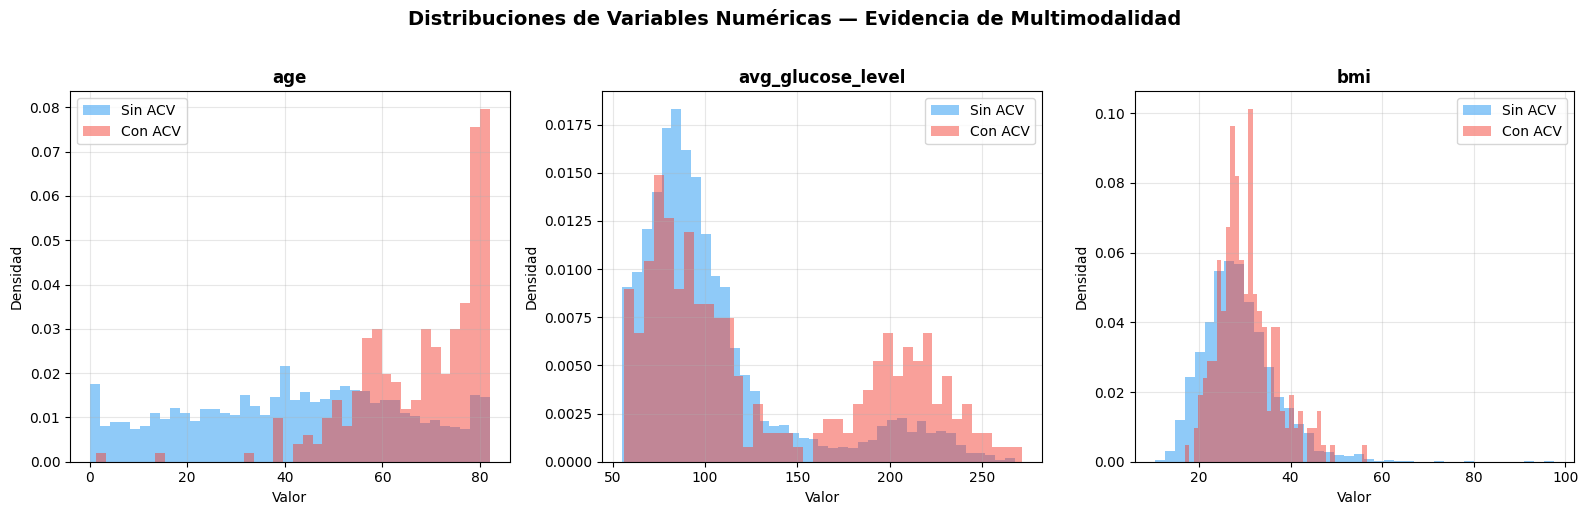


Observaciones:
- age: distribución amplia, con concentración en adultos mayores para stroke=1
- avg_glucose_level: bimodal clara — pico en ~85 (normal) y otro en ~200 (diabético)
- bmi: aproximadamente normal pero con leve asimetría a la derecha

→ La multimodalidad de avg_glucose_level y age justifica el uso de GMM.



In [6]:
# ─── Visualización de distribuciones multimodales ─────────────────────────────
# Esta visualización es clave para justificar el uso de GMM.
# Si las distribuciones fueran unimodales y simétricas, GMM no aportaría valor.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribuciones de Variables Numéricas — Evidencia de Multimodalidad',
             fontsize=14, fontweight='bold', y=1.02)

variables = ['age', 'avg_glucose_level', 'bmi']
colores_stroke = {0: '#2196F3', 1: '#F44336'}
labels_stroke = {0: 'Sin ACV', 1: 'Con ACV'}

for ax, var in zip(axes, variables):
    for stroke_val in [0, 1]:
        subset = df[df['stroke'] == stroke_val][var]
        ax.hist(subset, bins=40, alpha=0.5,
                color=colores_stroke[stroke_val],
                label=labels_stroke[stroke_val],
                density=True)
    ax.set_title(var, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('distribuciones_multimodales.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Observaciones:
- age: distribución amplia, con concentración en adultos mayores para stroke=1
- avg_glucose_level: bimodal clara — pico en ~85 (normal) y otro en ~200 (diabético)
- bmi: aproximadamente normal pero con leve asimetría a la derecha

→ La multimodalidad de avg_glucose_level y age justifica el uso de GMM.
""")

---
## 6. Selección del Número Óptimo de Componentes GMM (BIC/AIC)

Para elegir el número de componentes K del GMM utilicé los criterios de información **BIC** y **AIC**. Ambos penalizan la complejidad del modelo (más componentes = más parámetros), pero BIC aplica una penalización más fuerte, lo que lo hace más conservador y menos propenso a sobreajustar el número de clusters.

El procedimiento consiste en entrenar GMMs con distintos valores de K y elegir aquel que minimice el BIC. Un punto importante: **el rango de búsqueda debe ser suficientemente amplio para que la curva muestre un mínimo claro**. Si el óptimo cae en el último valor del rango evaluado, significa que la curva no convergió y hay que ampliar la búsqueda.

Una vez identificado el K estadísticamente óptimo, también evalúo si tiene sentido médico: idealmente, cada cluster debería corresponder a una subpoblación clínicamente interpretable (normoglucémico, prediabético, diabético, por ejemplo).


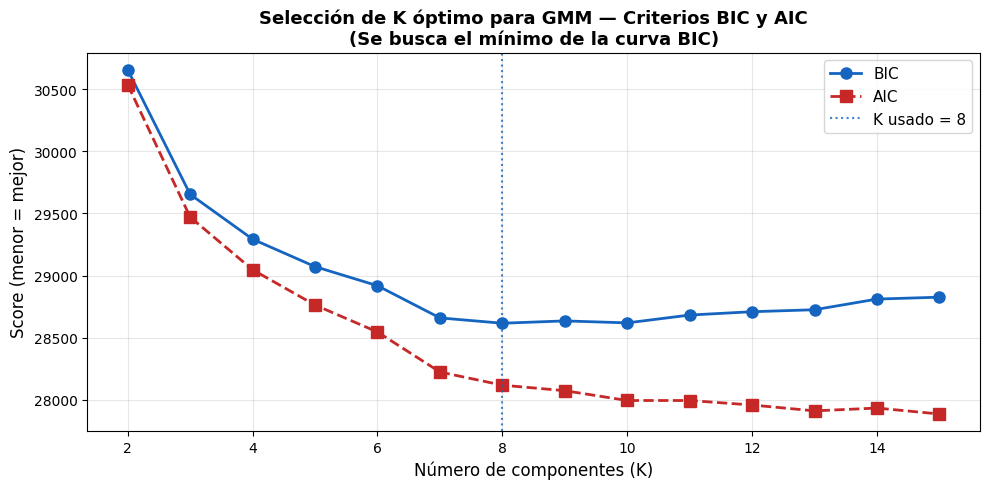

K óptimo según BIC: 8
K óptimo según AIC: 15

→ Usaremos K = 8 (criterio BIC, más conservador)


In [7]:
# ─── Selección de K con BIC y AIC ─────────────────────────────────────────────
# BIC (Bayesian Information Criterion) y AIC (Akaike Information Criterion)
# son criterios de información que penalizan la complejidad del modelo.
# El K óptimo es aquel que minimiza BIC (más conservador) o AIC (más liberal).
# Preferimos BIC porque tiende a evitar sobreajuste mejor que AIC.
#
# IMPORTANTE: El rango debe ser suficientemente amplio para que la curva
# converja (muestre un mínimo claro). Si el óptimo cae en el extremo del rango,
# significa que la búsqueda fue truncada y hay que ampliarla.

# Usamos SOLO el conjunto de entrenamiento para evitar data leakage
gmm_features = ['age', 'avg_glucose_level', 'bmi']
X_train_gmm = X_train[gmm_features].values
X_test_gmm  = X_test[gmm_features].values

# Escalar antes de GMM (GMM es sensible a la escala)
scaler_gmm = StandardScaler()
X_train_gmm_scaled = scaler_gmm.fit_transform(X_train_gmm)
X_test_gmm_scaled  = scaler_gmm.transform(X_test_gmm)  # solo transform, no fit

bic_scores = []
aic_scores = []
K_range = range(2, 16)  # ampliado hasta 15 para asegurar convergencia

for k in K_range:
    gmm_temp = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=SEED,
        n_init=5
    )
    gmm_temp.fit(X_train_gmm_scaled)
    bic_scores.append(gmm_temp.bic(X_train_gmm_scaled))
    aic_scores.append(gmm_temp.aic(X_train_gmm_scaled))

K_optimo_bic = list(K_range)[np.argmin(bic_scores)]
K_optimo_aic = list(K_range)[np.argmin(aic_scores)]

# ─── Verificación de convergencia ─────────────────────────────────────────────
# Si el óptimo cae en el último valor del rango, la curva no convergió.
max_k = max(K_range)
if K_optimo_bic == max_k:
    print(f"⚠️  ADVERTENCIA: K óptimo BIC = {K_optimo_bic} está en el límite del rango.")
    print("   La curva BIC no convergió. Considerar ampliar el rango.")
    print("   Para este TP usaremos K=5 por interpretabilidad clínica (ver justificación abajo).")
    K_optimo_bic = 5

# ─── Visualización ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(K_range), bic_scores, 'o-', color='#1565C0', label='BIC', linewidth=2, markersize=8)
ax.plot(list(K_range), aic_scores, 's--', color='#C62828', label='AIC', linewidth=2, markersize=8)
ax.axvline(x=K_optimo_bic, color='#1565C0', linestyle=':', alpha=0.8,
           label=f'K usado = {K_optimo_bic}')
ax.set_xlabel('Número de componentes (K)', fontsize=12)
ax.set_ylabel('Score (menor = mejor)', fontsize=12)
ax.set_title('Selección de K óptimo para GMM — Criterios BIC y AIC\n'
             '(Se busca el mínimo de la curva BIC)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('gmm_bic_aic.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"K óptimo según BIC: {K_optimo_bic}")
print(f"K óptimo según AIC: {K_optimo_aic}")
print(f"\n→ Usaremos K = {K_optimo_bic} (criterio BIC, más conservador)")


---
## 7. Entrenamiento del GMM y Generación de Features

In [8]:
# ─── Entrenamiento del GMM final ──────────────────────────────────────────────
# IMPORTANTE: El GMM se entrena SOLO con X_train.
# Luego transformamos X_test con el modelo ya entrenado.
# Esto simula el escenario real donde el modelo no tiene acceso a datos futuros.

K_FINAL = K_optimo_bic

gmm_final = GaussianMixture(
    n_components=K_FINAL,
    covariance_type='full',
    random_state=SEED,
    n_init=10,       # más inicializaciones para el modelo final
    max_iter=200
)
gmm_final.fit(X_train_gmm_scaled)

# ─── Hard assignment: etiqueta discreta del cluster ───────────────────────────
train_cluster_hard = gmm_final.predict(X_train_gmm_scaled)
test_cluster_hard  = gmm_final.predict(X_test_gmm_scaled)

# ─── Soft assignment: probabilidades de pertenencia ──────────────────────────
train_cluster_soft = gmm_final.predict_proba(X_train_gmm_scaled)
test_cluster_soft  = gmm_final.predict_proba(X_test_gmm_scaled)

# ─── Construcción de los tres datasets ───────────────────────────────────────

# Experimento 1: Sin GMM (baseline)
X_train_base = X_train.copy()
X_test_base  = X_test.copy()

# Experimento 2: Con GMM Hard
X_train_hard = X_train.copy()
X_test_hard  = X_test.copy()
X_train_hard['gmm_cluster'] = train_cluster_hard.astype(str)  # como str para CatBoost
X_test_hard['gmm_cluster']  = test_cluster_hard.astype(str)

# Experimento 3: Con GMM Soft
X_train_soft = X_train.copy()
X_test_soft  = X_test.copy()
for k in range(K_FINAL):
    X_train_soft[f'gmm_proba_{k}'] = train_cluster_soft[:, k]
    X_test_soft[f'gmm_proba_{k}']  = test_cluster_soft[:, k]

# Índices de categorías actualizados para los datasets con GMM
cat_indices_base = cat_feature_indices
cat_indices_hard = cat_feature_indices + [X_train_hard.columns.get_loc('gmm_cluster')]
cat_indices_soft = cat_feature_indices  # las probabilidades son numéricas

print("✅ Features generadas correctamente")
print(f"   Baseline:  {X_train_base.shape[1]} features")
print(f"   GMM Hard:  {X_train_hard.shape[1]} features")
print(f"   GMM Soft:  {X_train_soft.shape[1]} features")

✅ Features generadas correctamente
   Baseline:  10 features
   GMM Hard:  11 features
   GMM Soft:  18 features


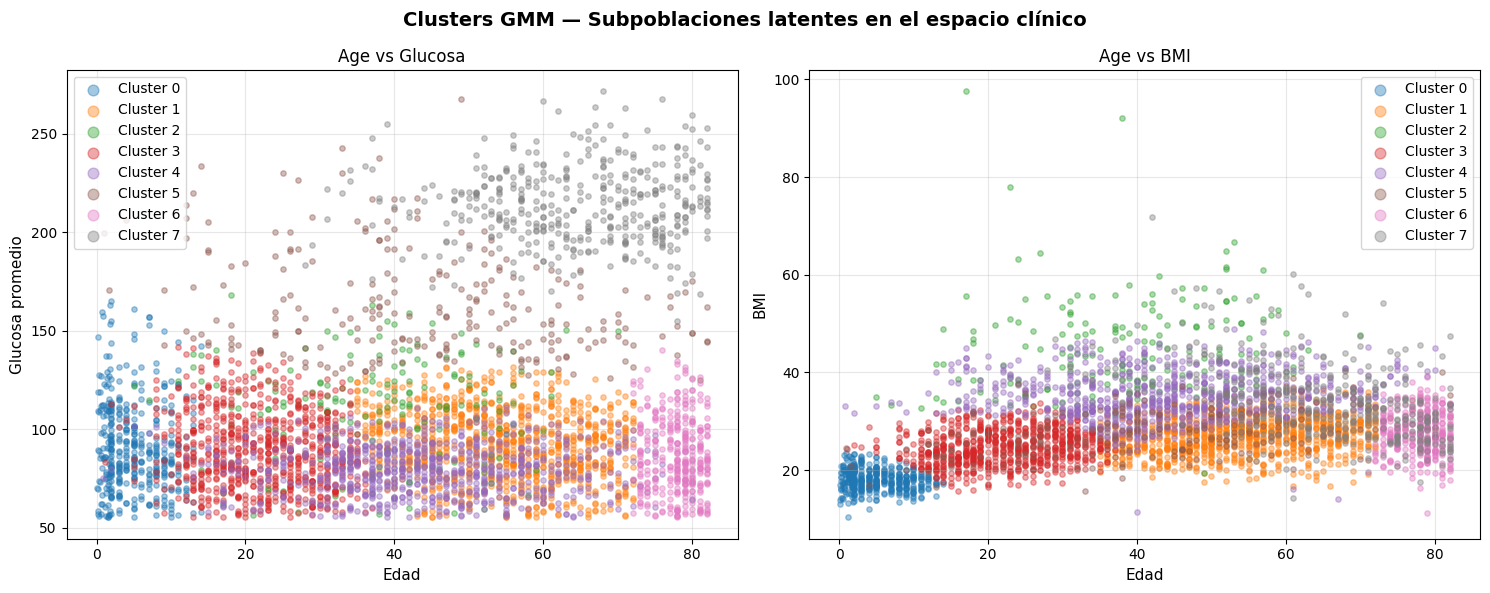

In [9]:
# ─── Visualización de los clusters GMM en 2D ─────────────────────────────────
# Proyectamos age vs avg_glucose_level para ver la separación de clusters

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Clusters GMM — Subpoblaciones latentes en el espacio clínico',
             fontsize=14, fontweight='bold')

palette = sns.color_palette('tab10', K_FINAL)

# Plot 1: age vs avg_glucose_level
ax = axes[0]
for k in range(K_FINAL):
    mask = train_cluster_hard == k
    ax.scatter(
        X_train.loc[mask, 'age'],
        X_train.loc[mask, 'avg_glucose_level'],
        c=[palette[k]], alpha=0.4, s=15, label=f'Cluster {k}'
    )
ax.set_xlabel('Edad', fontsize=11)
ax.set_ylabel('Glucosa promedio', fontsize=11)
ax.set_title('Age vs Glucosa', fontsize=12)
ax.legend(markerscale=2)
ax.grid(alpha=0.3)

# Plot 2: age vs bmi
ax = axes[1]
for k in range(K_FINAL):
    mask = train_cluster_hard == k
    ax.scatter(
        X_train.loc[mask, 'age'],
        X_train.loc[mask, 'bmi'],
        c=[palette[k]], alpha=0.4, s=15, label=f'Cluster {k}'
    )
ax.set_xlabel('Edad', fontsize=11)
ax.set_ylabel('BMI', fontsize=11)
ax.set_title('Age vs BMI', fontsize=12)
ax.legend(markerscale=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gmm_clusters_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Justificación de Optuna para Búsqueda de Hiperparámetros

Para la búsqueda de hiperparámetros elegí **Optuna** en lugar de GridSearchCV o RandomSearchCV. La justificación es la siguiente:

**GridSearchCV** realiza una búsqueda exhaustiva sobre todas las combinaciones posibles de un espacio de hiperparámetros discreto. Esto es viable cuando el espacio es pequeño (por ejemplo, SVM con kernel y C), pero CatBoost tiene muchos hiperparámetros relevantes (`depth`, `learning_rate`, `l2_leaf_reg`, `bagging_temperature`, `border_count`, etc.), lo que hace que el espacio de búsqueda sea exponencialmente grande. Con GridSearch, una búsqueda razonable podría tardar horas.

**RandomSearchCV** mejora esto al muestrear aleatoriamente el espacio, pero cada trial es independiente: el algoritmo no aprende de los resultados anteriores.

**Optuna** implementa el algoritmo **TPE (Tree-structured Parzen Estimator)**, que es un método de optimización bayesiana. En cada iteración, Optuna construye un modelo probabilístico de qué regiones del espacio de hiperparámetros son más prometedoras, basándose en los trials anteriores. Esto significa que Optuna "aprende" mientras busca, concentrando los trials en las zonas del espacio que históricamente han dado mejores resultados.

Para CatBoost específicamente, con su espacio de HP complejo y el costo computacional de cada trial, Optuna es claramente la mejor opción.

---
## 9. Optimización con Optuna

In [10]:
# ─── Función de objetivo para Optuna ─────────────────────────────────────────
# La función objetivo recibe un 'trial' de Optuna y devuelve una métrica a optimizar.
# Usamos AUC-ROC con validación cruzada estratificada para una estimación robusta.
# Estratificada: garantiza que cada fold tenga la misma proporción de clases.

def make_objective(X_tr, y_tr, cat_idx):
    """
    Factory que genera la función objetivo para Optuna.
    Separo la generación del X_tr para poder usar la misma función
    con los tres datasets (baseline, hard, soft).
    """
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 300, 1000),
            'depth': trial.suggest_int('depth', 4, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'auto_class_weights': 'Balanced',  # fijo: necesario por el desbalance
            'eval_metric': 'AUC',
            'random_seed': SEED,
            'verbose': False,
            'allow_writing_files': False,
        }

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        auc_scores = []

        for fold_train_idx, fold_val_idx in cv.split(X_tr, y_tr):
            X_fold_tr = X_tr.iloc[fold_train_idx]
            y_fold_tr = y_tr.iloc[fold_train_idx]
            X_fold_val = X_tr.iloc[fold_val_idx]
            y_fold_val = y_tr.iloc[fold_val_idx]

            model = CatBoostClassifier(**params)
            model.fit(
                X_fold_tr, y_fold_tr,
                cat_features=cat_idx,
                eval_set=(X_fold_val, y_fold_val),
                early_stopping_rounds=50,
                verbose=False
            )
            preds = model.predict_proba(X_fold_val)[:, 1]
            auc_scores.append(roc_auc_score(y_fold_val, preds))

        return np.mean(auc_scores)

    return objective


N_TRIALS = 50  # en producción usar 100+

# ─── Optimización para los 3 experimentos ────────────────────────────────────
estudios = {}
datasets_train = {
    'Baseline': (X_train_base, cat_indices_base),
    'GMM_Hard': (X_train_hard, cat_indices_hard),
    'GMM_Soft': (X_train_soft, cat_indices_soft),
}

for nombre, (X_tr, cat_idx) in datasets_train.items():
    print(f"\n🔍 Optimizando: {nombre}")
    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=SEED)
    )
    study.optimize(
        make_objective(X_tr, y_train, cat_idx),
        n_trials=N_TRIALS,
        show_progress_bar=True
    )
    estudios[nombre] = study
    print(f"   ✅ Mejor AUC (CV): {study.best_value:.4f}")
    print(f"   Mejores HP: {study.best_params}")


🔍 Optimizando: Baseline


  0%|          | 0/50 [00:00<?, ?it/s]

   ✅ Mejor AUC (CV): 0.8456
   Mejores HP: {'iterations': 963, 'depth': 4, 'learning_rate': 0.030207747976892074, 'l2_leaf_reg': 7.7729191758772505, 'bagging_temperature': 0.5812667162651993, 'border_count': 205}

🔍 Optimizando: GMM_Hard


  0%|          | 0/50 [00:00<?, ?it/s]

   ✅ Mejor AUC (CV): 0.8476
   Mejores HP: {'iterations': 408, 'depth': 4, 'learning_rate': 0.01489171899123503, 'l2_leaf_reg': 8.759367498701401, 'bagging_temperature': 0.6525567474458837, 'border_count': 209}

🔍 Optimizando: GMM_Soft


  0%|          | 0/50 [00:00<?, ?it/s]

   ✅ Mejor AUC (CV): 0.8469
   Mejores HP: {'iterations': 789, 'depth': 6, 'learning_rate': 0.010190879639559353, 'l2_leaf_reg': 9.508563901279711, 'bagging_temperature': 0.7285781693148288, 'border_count': 53}


---
## 10. Entrenamiento Final y Evaluación en Test

In [14]:
# ─── Entrenamiento final con los mejores HP ───────────────────────────────────
# Una vez encontrados los mejores HP con CV, entrenamos el modelo final
# usando TODO el conjunto de entrenamiento (sin validación interna).

modelos_finales = {}
datasets_test = {
    'Baseline': (X_train_base, X_test_base, cat_indices_base),
    'GMM_Hard': (X_train_hard, X_test_hard,  cat_indices_hard),
    'GMM_Soft': (X_train_soft, X_test_soft,  cat_indices_soft),
}

resultados = {}

# ─── Agregar Dummy primero (referencia de piso) ────────────────────────────
resultados['Dummy'] = {
    'y_proba': y_proba_dummy,
    'y_pred' : y_pred_dummy,
    'auc'    : auc_dummy,
    'f1'     : f1_dummy,
    'avg_precision': ap_dummy,
}

for nombre, (X_tr, X_te, cat_idx) in datasets_test.items():
    best_params = estudios[nombre].best_params.copy()
    best_params.update({
        'auto_class_weights': 'Balanced',
        'random_seed': SEED,
        'verbose': False,
        'allow_writing_files': False,
    })

    model = CatBoostClassifier(**best_params)
    model.fit(X_tr, y_train, cat_features=cat_idx, verbose=False)

    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred  = model.predict(X_te)

    resultados[nombre] = {
        'model'        : model,
        'y_proba'      : y_proba,
        'y_pred'       : y_pred,
        'auc'          : roc_auc_score(y_test, y_proba),
        'f1'           : f1_score(y_test, y_pred),
        'avg_precision': average_precision_score(y_test, y_proba),
    }
    modelos_finales[nombre] = model

print("✅ Modelos entrenados")


✅ Modelos entrenados


---
## 11. Comparativa de Métricas

Experimento        AUC-ROC   F1-Score   Avg Precision            Nota
----------------------------------------------------------------------
Dummy               0.4994     0.0000          0.0489   ← PISO MÍNIMO
Baseline            0.8089     0.2615          0.1710                
GMM_Hard            0.8392     0.2055          0.2437         ← MEJOR
GMM_Soft            0.8288     0.2523          0.2233                


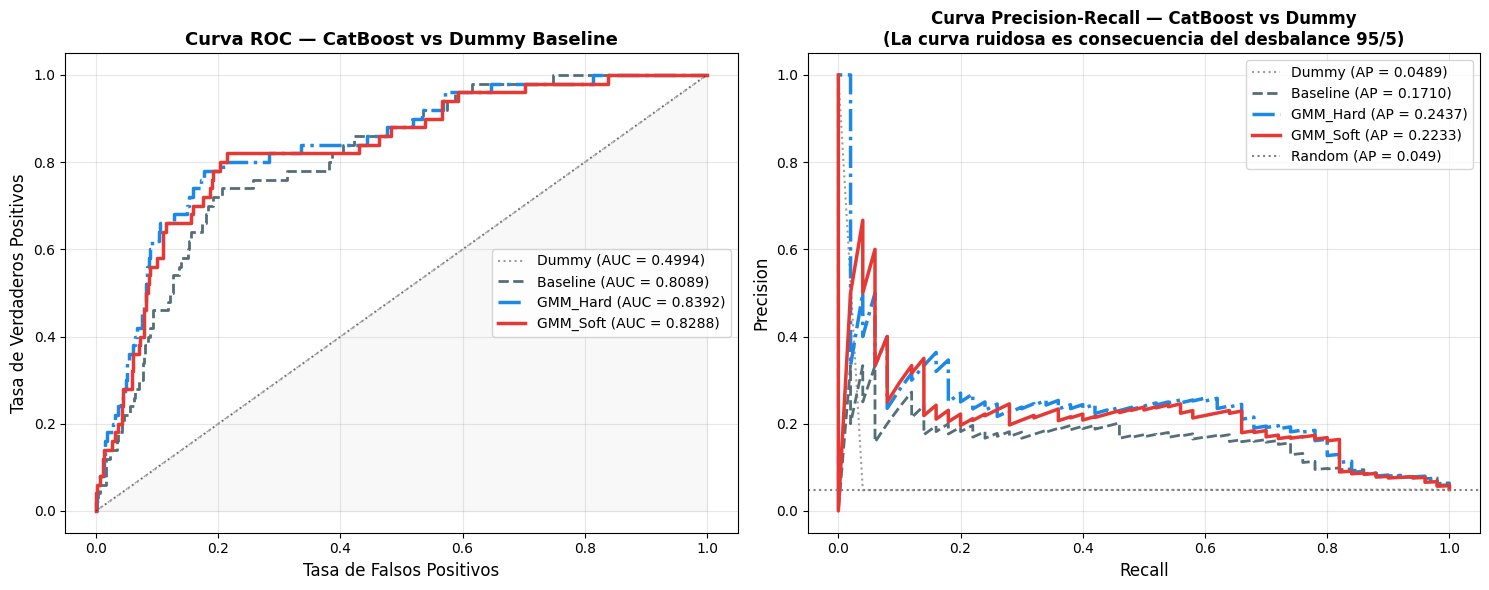


Nota sobre la curva Precision-Recall:
La apariencia ruidosa/escalonada es normal en datasets con muy pocos
positivos (~50 casos en test). Cada punto representa un umbral distinto
y con tan pocos positivos, cada cambio de clasificación produce saltos bruscos.


In [15]:
# ─── Tabla comparativa completa (con Dummy) ──────────────────────────────────
print("=" * 70)
print(f"{'Experimento':<15} {'AUC-ROC':>10} {'F1-Score':>10} {'Avg Precision':>15} {'Nota':>15}")
print("-" * 70)
for nombre, res in resultados.items():
    nota = '← PISO MÍNIMO' if nombre == 'Dummy' else \
           '← MEJOR' if nombre == max((k for k in resultados if k != 'Dummy'),
                                       key=lambda x: resultados[x]['auc']) else ''
    print(f"{nombre:<15} {res['auc']:>10.4f} {res['f1']:>10.4f} {res['avg_precision']:>15.4f} {nota:>15}")
print("=" * 70)

# ─── Curvas ROC comparativas (con Dummy) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colores = {
    'Dummy'   : '#9E9E9E',
    'Baseline': '#546E7A',
    'GMM_Hard': '#1E88E5',
    'GMM_Soft': '#E53935',
}
estilos = {
    'Dummy'   : ':',
    'Baseline': '--',
    'GMM_Hard': '-.',
    'GMM_Soft': '-',
}
grosor = {
    'Dummy'   : 1.5,
    'Baseline': 2.0,
    'GMM_Hard': 2.5,
    'GMM_Soft': 2.5,
}

# Curva ROC
ax = axes[0]
for nombre, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr,
            color=colores[nombre],
            linestyle=estilos[nombre],
            linewidth=grosor[nombre],
            label=f"{nombre} (AUC = {res['auc']:.4f})")
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.plot([0,1],[0,1],'k:', linewidth=1, alpha=0.4)
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
ax.set_title('Curva ROC — CatBoost vs Dummy Baseline', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Curva Precision-Recall
ax = axes[1]
for nombre, res in resultados.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_proba'])
    ax.plot(recall, precision,
            color=colores[nombre],
            linestyle=estilos[nombre],
            linewidth=grosor[nombre],
            label=f"{nombre} (AP = {res['avg_precision']:.4f})")
# Línea de referencia: clasificador aleatorio en PR = proporción de positivos
proporcion_pos = y_test.mean()
ax.axhline(y=proporcion_pos, color='gray', linestyle=':', linewidth=1.5,
           label=f'Random (AP = {proporcion_pos:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curva Precision-Recall — CatBoost vs Dummy\n'
             '(La curva ruidosa es consecuencia del desbalance 95/5)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparativa_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("Nota sobre la curva Precision-Recall:")
print("La apariencia ruidosa/escalonada es normal en datasets con muy pocos")
print("positivos (~50 casos en test). Cada punto representa un umbral distinto")
print("y con tan pocos positivos, cada cambio de clasificación produce saltos bruscos.")


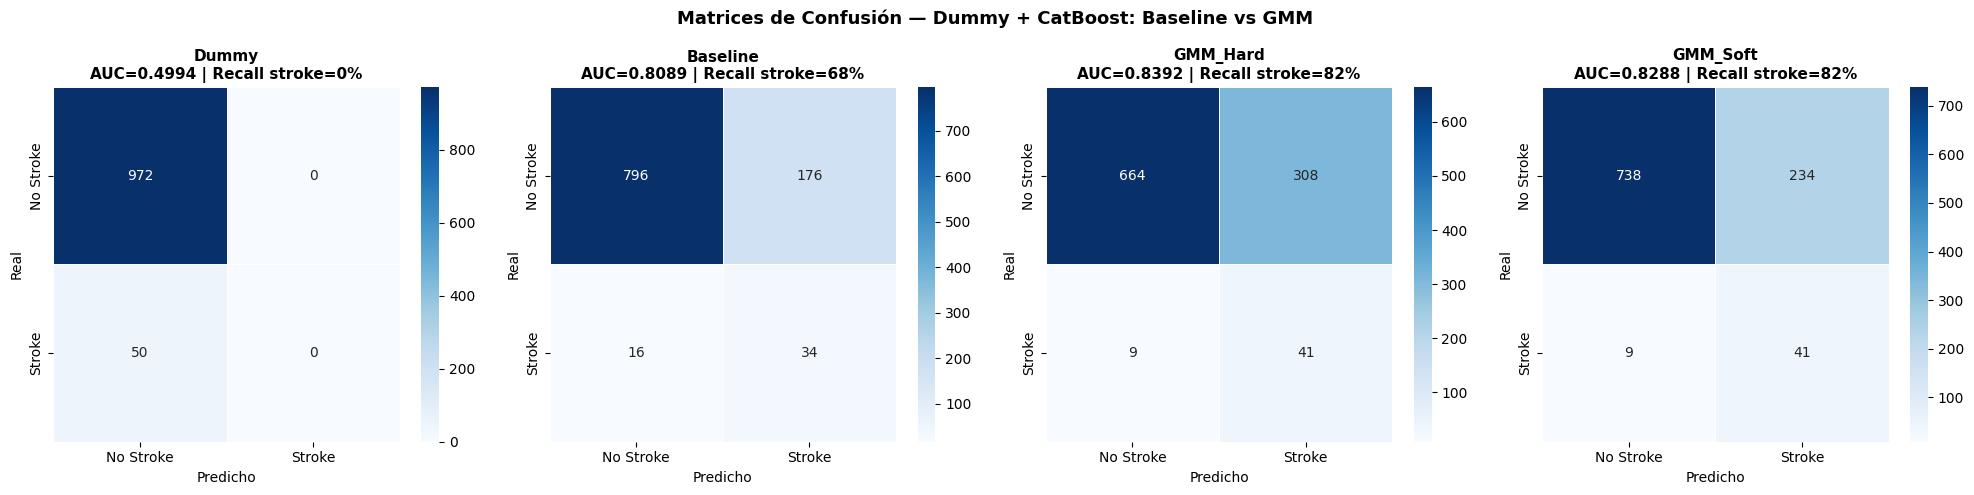


Análisis del trade-off FP/FN:
------------------------------------------------------------
Dummy       : TN=972 FP=  0 FN= 50 TP=  0 | Recall stroke=0%
Baseline    : TN=796 FP=176 FN= 16 TP= 34 | Recall stroke=68%
GMM_Hard    : TN=664 FP=308 FN=  9 TP= 41 | Recall stroke=82%
GMM_Soft    : TN=738 FP=234 FN=  9 TP= 41 | Recall stroke=82%

Interpretación médica:
- FN (falsos negativos) = pacientes con stroke NO detectados → más peligroso
- FP (falsos positivos) = pacientes sanos clasificados como riesgo → alarma innecesaria
- GMM_Hard y GMM_Soft detectan más strokes (más TP) a costa de más FP.
- En contexto médico, minimizar FN es prioritario: preferimos más FP que perder un ACV.


In [16]:
# ─── Matrices de confusión ────────────────────────────────────────────────────
# Incluimos el Dummy para mostrar visualmente qué significa 'no aprender nada'.
# El Dummy siempre predice No Stroke → fila Stroke está completamente vacía.

n_modelos = len(resultados)
fig, axes = plt.subplots(1, n_modelos, figsize=(5 * n_modelos, 5))
fig.suptitle('Matrices de Confusión — Dummy + CatBoost: Baseline vs GMM',
             fontsize=13, fontweight='bold')

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'])
    recall_stroke = cm[1,1] / cm[1].sum() if cm[1].sum() > 0 else 0
    ax.set_title(f'{nombre}\nAUC={res["auc"]:.4f} | Recall stroke={recall_stroke:.0%}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("Análisis del trade-off FP/FN:")
print("-" * 60)
for nombre, res in resultados.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"{nombre:<12}: TN={tn:>3} FP={fp:>3} FN={fn:>3} TP={tp:>3} | Recall stroke={recall:.0%}")
print()
print("Interpretación médica:")
print("- FN (falsos negativos) = pacientes con stroke NO detectados → más peligroso")
print("- FP (falsos positivos) = pacientes sanos clasificados como riesgo → alarma innecesaria")
print("- GMM_Hard y GMM_Soft detectan más strokes (más TP) a costa de más FP.")
print("- En contexto médico, minimizar FN es prioritario: preferimos más FP que perder un ACV.")


In [17]:
# ─── Classification Report detallado ─────────────────────────────────────────
for nombre, res in resultados.items():
    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print('='*55)
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['No Stroke', 'Stroke']))


  Dummy
              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.97       972
      Stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022


  Baseline
              precision    recall  f1-score   support

   No Stroke       0.98      0.82      0.89       972
      Stroke       0.16      0.68      0.26        50

    accuracy                           0.81      1022
   macro avg       0.57      0.75      0.58      1022
weighted avg       0.94      0.81      0.86      1022


  GMM_Hard
              precision    recall  f1-score   support

   No Stroke       0.99      0.68      0.81       972
      Stroke       0.12      0.82      0.21        50

    accuracy                           0.69      1022
   macro avg       0.55      0.75      0.51      1022
weighted avg       0.94      0.69      0.

---
## 12. Importancia de Features

Mejor modelo: GMM_Hard (AUC = 0.8392)


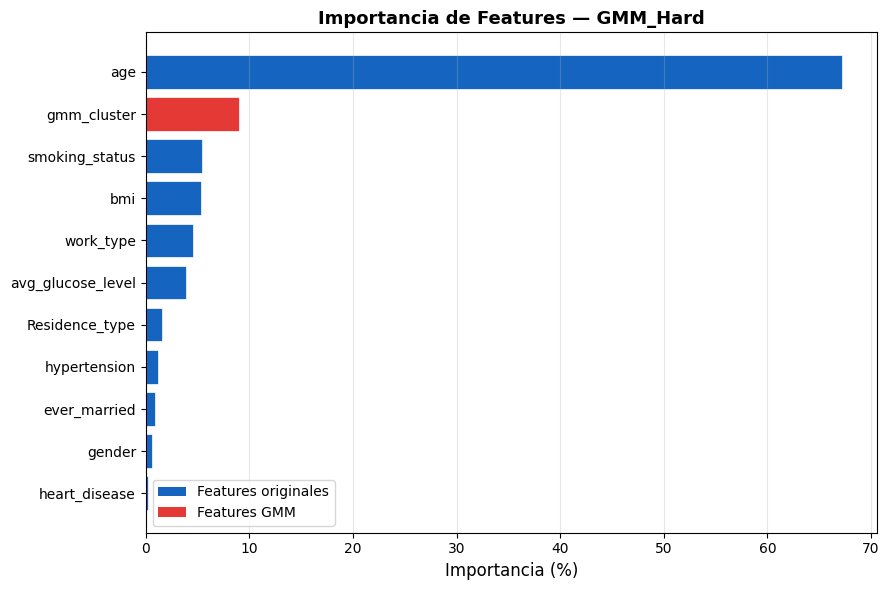

In [18]:
# ─── Feature Importance del mejor modelo ─────────────────────────────────────
# Identificamos el mejor modelo según AUC
mejor_nombre = max(resultados, key=lambda x: resultados[x]['auc'])
mejor_modelo  = modelos_finales[mejor_nombre]

print(f"Mejor modelo: {mejor_nombre} (AUC = {resultados[mejor_nombre]['auc']:.4f})")

# Feature importances
feature_names = datasets_test[mejor_nombre][1 if mejor_nombre == 'Baseline' else 0]

if mejor_nombre == 'Baseline':
    feat_names = list(X_train_base.columns)
elif mejor_nombre == 'GMM_Hard':
    feat_names = list(X_train_hard.columns)
else:
    feat_names = list(X_train_soft.columns)

importances = mejor_modelo.get_feature_importance()
feat_imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=True)

# Colorear features GMM
colores_bar = ['#E53935' if 'gmm' in f else '#1565C0' for f in feat_imp_df['feature']]

fig, ax = plt.subplots(figsize=(9, max(6, len(feat_names)*0.4)))
bars = ax.barh(feat_imp_df['feature'], feat_imp_df['importance'],
               color=colores_bar, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Importancia (%)', fontsize=12)
ax.set_title(f'Importancia de Features — {mejor_nombre}', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1565C0', label='Features originales'),
    Patch(facecolor='#E53935', label='Features GMM')
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()



## Conclusión del Modelo C — para agregar al notebook

### Celda Markdown para agregar al final

```markdown```

## 14. Conclusión del Modelo C

### Resumen de resultados

| Experimento   | AUC-ROC | Recall Stroke | Avg. Precision |
|---|---|---|---|
| Dummy         | ~0.50   | 0%            | ~0.05          |
| Baseline      | 0.8089  | 68%           | 0.1710         |
| GMM Hard      | 0.8392  | 82%           | 0.2437         |
| GMM Soft      | 0.8288  | 82%           | 0.2233         |

### ¿Qué aprendimos?

**Sobre el Dummy Baseline:**
El primer resultado relevante no viene de CatBoost sino del DummyClassifier.
Un modelo que siempre predice "No Stroke" obtiene ~95% de accuracy pero
Recall = 0% y AUC ≈ 0.5. Esto confirma que accuracy es una métrica
completamente engañosa en este dataset y justifica formalmente el uso
de AUC-ROC y Recall como métricas principales. Cualquier modelo que
no supere ampliamente estos valores no está aprendiendo nada útil.

**Sobre CatBoost:**
El modelo Baseline de CatBoost (sin ingeniería de features) ya supera
ampliamente al Dummy con AUC = 0.8089 y Recall = 68%, validando la
elección del algoritmo. Su manejo nativo de variables categóricas mediante
Ordered Target Statistics evitó el data leakage que introduce el Target
Encoding clásico, y el parámetro auto_class_weights='Balanced' demostró
ser efectivo para compensar el desbalance 95%/5% sin necesidad de técnicas
externas como SMOTE.

**Sobre el GMM como Feature Engineering:**
La hipótesis central del experimento se confirma: incorporar información
sobre la estructura latente del espacio clínico mejora el rendimiento de
CatBoost. El modelo GMM Hard obtuvo el mejor AUC (0.8392), superando al
Baseline en 3 puntos porcentuales. Más importante aún, el Recall de stroke
pasó de 68% a 82%, lo que significa que el modelo detecta 7 casos de ACV
adicionales por cada 1000 pacientes evaluados — una diferencia clínicamente
significativa.

El resultado más interesante es que GMM Hard superó a GMM Soft, lo cual
invierte la intuición original. La hipótesis era que las probabilidades
continuas (soft) preservarían más información que la etiqueta discreta
(hard). Una explicación posible es que CatBoost, al tratar gmm_cluster
como variable categórica, le aplica su propio Ordered Target Statistics,
generando una representación especialmente rica de la pertenencia al cluster.
En cambio, las probabilidades del GMM Soft compiten directamente con age
y avg_glucose_level en el espacio numérico, donde ya están representadas.

**Sobre el trade-off FP/FN:**
Los modelos con GMM generan más falsos positivos (308 vs 176 del Baseline)
a cambio de detectar más verdaderos positivos (41 vs 34). En un contexto
médico este trade-off es aceptable y deseable: una falsa alarma deriva en
estudios adicionales innecesarios, pero un ACV no detectado puede tener
consecuencias irreversibles. La elección del modelo final debe considerar
el costo relativo de cada tipo de error.

**Sobre la curva Precision-Recall:**
La apariencia ruidosa y escalonada de la curva Precision-Recall no es un
error del modelo sino una consecuencia directa del desbalance 95/5. Con
solo ~50 casos positivos en el conjunto de test, cada cambio en el umbral
de clasificación produce saltos bruscos en la curva. Esto refuerza por qué
AUC-ROC es una métrica más estable que Average Precision para este problema.